In [5]:
from econml.grf import CausalForest, CausalIVForest, RegressionForest
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from scipy.special import expit

In [6]:
# 设置随机种子以确保结果可复现
np.random.seed(123)

# 定义样本数量、特征数量和处理数量
n_samples = 2000
n_features = 10
n_treatments = 1

# 定义真实的处理效应函数
# true_te = lambda X: np.hstack([X[:, [0]]**2 + 1, np.ones((X.shape[0], n_treatments - 1))])
# true_te = lambda X: np.hstack([X[:, [0]]>0, np.ones((X.shape[0], n_treatments - 1))])

# 这里定义了一个处理效应，其中第一个处理效应基于X的第一列是否大于0，第二个处理效应是一个常数向量
true_te = lambda X: np.hstack([(X[:, [0]] > 0) * X[:, [0]],
                               np.ones((X.shape[0], n_treatments - 1)) * np.arange(1, n_treatments).reshape(1, -1)])

# 生成特征矩阵X和处理向量T
X = np.random.normal(0, 1, size=(n_samples, n_features))
T = np.random.normal(0, 1, size=(n_samples, n_treatments))

# 根据逻辑回归模型生成处理分配
for t in range(n_treatments):
    T[:, t] = np.random.binomial(1, expit(X[:, 0]))

# 生成结果变量y，其中包含了处理效应和随机噪声
y = np.sum(true_te(X) * T, axis=1, keepdims=True) + np.random.normal(0, .5, size=(n_samples, 1))

# 准备测试集X_test，这里只取了前100个样本，并在第一个特征上进行了值的扩展
X_test = X[:min(100, n_samples)].copy()
X_test[:, 0] = np.linspace(np.percentile(X[:, 0], 1), np.percentile(X[:, 0], 99), min(100, n_samples))

# 初始化CausalForest估计器，指定超参数
est = CausalForest(criterion='het', n_estimators=400, min_samples_leaf=5, max_depth=None,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                   min_impurity_decrease=0.0, max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)

In [7]:
est.fit(X, T, y)
"""
X：特征矩阵，通常是一个二维数组或DataFrame，其中每一行代表一个样本，每一列代表一个特征。在因果推断中，这些特征用于帮助估计处理效应。

T：处理向量，是一个一维或二维数组，表示每个样本是否接受了处理。在二维情况下，每一列可以代表不同的处理组别。在因果森林中，这个向量用于识别哪些样本属于处理组，哪些属于控制组。

y：结果向量，是一个一维数组，表示每个样本的结果变量的观测值。在因果效应模型中，y是我们试图理解处理效应如何影响的变量。
"""

'\nX：特征矩阵，通常是一个二维数组或DataFrame，其中每一行代表一个样本，每一列代表一个特征。在因果推断中，这些特征用于帮助估计处理效应。\n\nT：处理向量，是一个一维或二维数组，表示每个样本是否接受了处理。在二维情况下，每一列可以代表不同的处理组别。在因果森林中，这个向量用于识别哪些样本属于处理组，哪些属于控制组。\n\ny：结果向量，是一个一维数组，表示每个样本的结果变量的观测值。在因果效应模型中，y是我们试图理解处理效应如何影响的变量。\n'

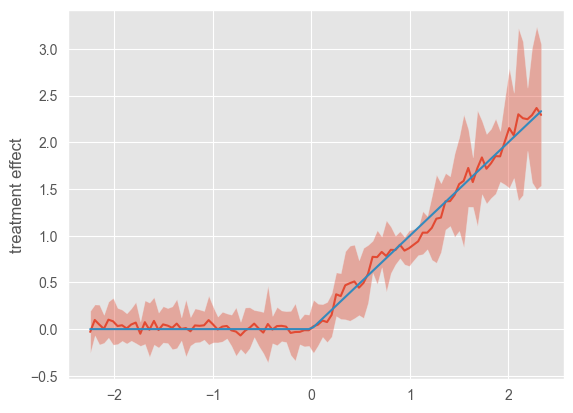

'\npoint, lb, ub = est.predict(X_test, interval=True, alpha=0.01)：这行代码调用了CausalForest估计器的predict方法，预测了测试集X_test的处理效应，并计算了置信区间。interval=True表示需要置信区间，alpha=0.01表示置信水平为99%，即置信区间不包含真实值的概率为1%。lb和ub分别是置信区间的下界和上界。\n\npoint = est.predict(X_test)：这行代码再次调用predict方法，但这次没有计算置信区间，只是获取了处理效应的点估计。\nx轴表示特征X_test[:, 0]的值，通常是某个连续变量。\ny轴表示处理效应的大小，即处理对结果变量的影响。\n蓝色线条表示预测的处理效应。\n红色阴影区域表示预测处理效应的99%置信区间，反映了预测的不确定性。\n红色线条表示真实的处理效应，用于与预测值进行比较。\n从图中可以看出，随着X_test[:, 0]的增加，处理效应也在增加。置信区间的宽度反映了预测的不确定性，随着X_test[:, 0]的增加，不确定性似乎也在增加。\n'

In [8]:
point, lb, ub = est.predict(X_test, interval=True, alpha=0.01)
point = est.predict(X_test)
plt.style.use('ggplot')
for t in range(n_treatments):
    plt.plot(X_test[:, 0], point[:, t])
    if est.inference:
        plt.fill_between(X_test[:, 0], lb[:, t], ub[:, t], alpha=.4)
    plt.plot(X_test[:, 0], true_te(X_test)[:, t])
plt.ylabel('treatment effect')
plt.show()
'''
point, lb, ub = est.predict(X_test, interval=True, alpha=0.01)：这行代码调用了CausalForest估计器的predict方法，预测了测试集X_test的处理效应，并计算了置信区间。interval=True表示需要置信区间，alpha=0.01表示置信水平为99%，即置信区间不包含真实值的概率为1%。lb和ub分别是置信区间的下界和上界。

point = est.predict(X_test)：这行代码再次调用predict方法，但这次没有计算置信区间，只是获取了处理效应的点估计。
x轴表示特征X_test[:, 0]的值，通常是某个连续变量。
y轴表示处理效应的大小，即处理对结果变量的影响。
蓝色线条表示预测的处理效应。
红色阴影区域表示预测处理效应的99%置信区间，反映了预测的不确定性。
红色线条表示真实的处理效应，用于与预测值进行比较。
从图中可以看出，随着X_test[:, 0]的增加，处理效应也在增加。置信区间的宽度反映了预测的不确定性，随着X_test[:, 0]的增加，不确定性似乎也在增加。
'''

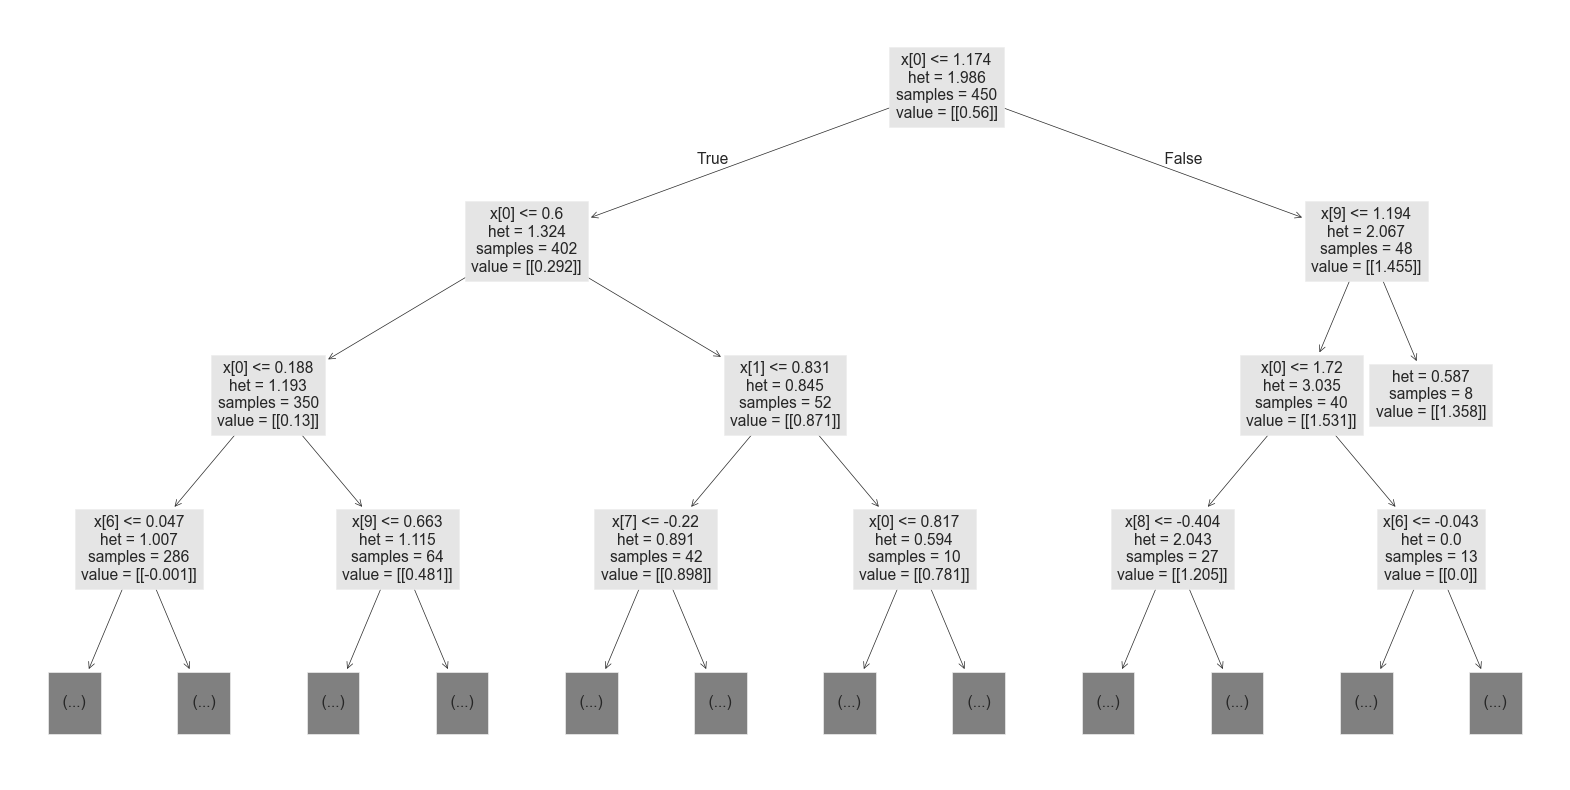

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(est[0], impurity=True, max_depth=3)
plt.show()

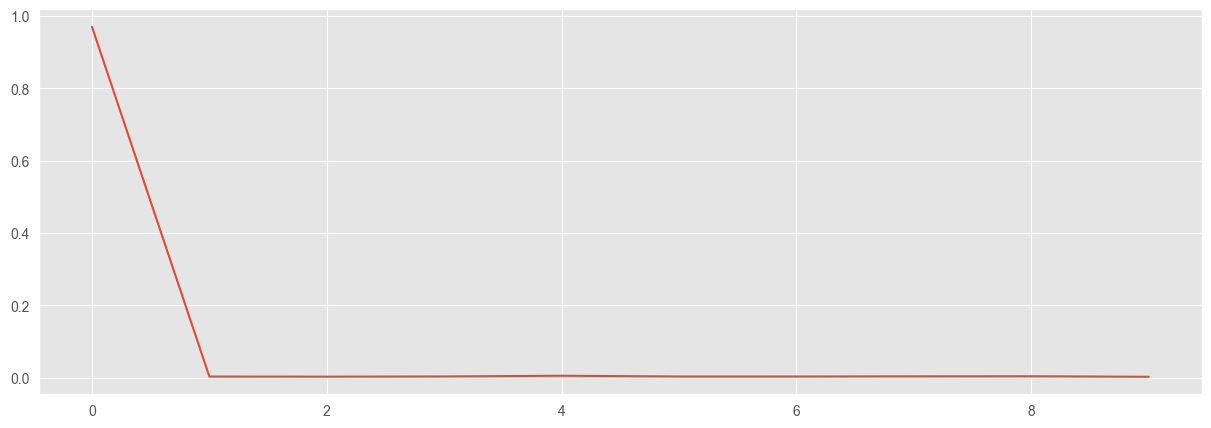

'\n图形解释：\n\nx轴通常表示特征的索引或者特征本身，但在这个图中没有明确标注。\ny轴表示特征的重要性，数值越大表示该特征在模型中越重要。\n从图中可以看出，第一个特征的重要性远高于其他特征，这可能意味着在估计处理效应时，第一个特征对模型的预测能力贡献最大。\n在第一个特征之后，特征重要性迅速下降并接近于零，这表明其他特征对模型的预测能力贡献较小或者几乎没有贡献。\n'

In [10]:
plt.figure(figsize=(15,5))
plt.plot(est.feature_importances(max_depth=4, depth_decay_exponent=2.0))
plt.show()
'''
图形解释：

x轴通常表示特征的索引或者特征本身，但在这个图中没有明确标注。
y轴表示特征的重要性，数值越大表示该特征在模型中越重要。
从图中可以看出，第一个特征的重要性远高于其他特征，这可能意味着在估计处理效应时，第一个特征对模型的预测能力贡献最大。
在第一个特征之后，特征重要性迅速下降并接近于零，这表明其他特征对模型的预测能力贡献较小或者几乎没有贡献。
'''